# Demo de implementación de un algoritmo genérico de Computación Evolutiva (CE) para resolver un SUDOKU intentando reducir la cantidad de errores
Utiliza la librería DEAP disponible en https://deap.readthedocs.io/en/master/

In [1]:
#@title Instalar librerías
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.6/135.6 kB 5.6 MB/s eta 0:00:00


In [2]:
#@title Cargar librerías
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from deap import base
from deap import creator
from deap import tools

import copy

import matplotlib
import matplotlib.pyplot as plt
import networkx
from IPython.display import display
from PIL import Image

import matplotlib as mpl
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import ipywidgets as widgets
from ipywidgets import Box, Layout, IntSlider
from ipywidgets import Layout
from IPython.display import clear_output

print("\nLibrerías importadas")


Librerías importadas



# Configuración:

In [3]:
#@title PARÁMETROS

#@markdown Parámetros del Algoritmo de Computación Evolutiva Genérico:

# Cantidad de Ciclos de la Corrida
CANT_CICLOS = 10000 #@param {type:"integer"}

# Indica que finaliza corrida cuando se alcance una  Aptitud Mínima (opcional)
FINALIZA_CORRIDA_POR_APTITUD = True  #@param {type:"boolean"}


# Cantidad de Individuos en la Población
CANT_INDIVIDUOS_POBLACION = 50 #@param {type:"slider", min:1, max:100, step:1}

print("\nParámetros de la Corrida definidos")


Parámetros de la Corrida definidos


In [4]:
#@title clase SUDOKU

# @markdown Tamaño del Tablero:
Tamaño_Sudoku_NxN = '9x9'  #@param [ '4x4', '9x9', '16x16', '25x25' ]
# @markdown Indica cómo se asignan valores predefinidos del Tablero (Manual o Azar):
Manual_Valores_Predefinidos_Lista = '  4  7 3            5   7        2   6  73      8     8     3   4 3   7 1    89 6' #@param {type:"string"}
Azar_Cantidad_Valores_Predefinidos = 5 # @param {type:"slider", min:0, max:25, step:1}

# posibles valores a usar en el sudoku
SUDOKU_VALORES_POSIBLES = [' ', '1','2','3','4','5','6','7','8','9', '0', 'A','B','C','D','E','F','G','H','I','J','K','L','M','N','Ñ','O','P','Q','R','S','T','U','V','W','X','Y','Z', '!','?','#','$','%','&','/','+','*','-']

# clase Sudoku
class Sudoku(object):

    def __init__(self, Tamaño_NxN='9x9'):
      # determina tamaño del tablero (siempre es cuadrado)
      try:
        self._N = int(Tamaño_NxN.lower().split("x")[0])
      except:
        print("No se puede definir tamaño del tablero, se usa valor por defecto 9x9!")
      # determina tamaño filas / columnas (N - 1)
      self._tamFilaCol = self._N-1
      # obtiene el tamaño de las regiones (raiz cuadrada de N)
      self._tamRegion = int(self._N**0.5)
      if (self._tamRegion**2) !=  self._N:
        # controla que el tamaño es un cuadrado perfecto
        raise Exception("El tamaño del tablero no es válido: " + str(self._N) + "x" + str(self._N) + "!")
      # determina valores a usar
      if len(SUDOKU_VALORES_POSIBLES) < (self._N+1):
        # controla que haya definidos valores para tamaño tablero
        raise Exception("No existen suficientes valores (" + str(len(SUDOKU_VALORES_POSIBLES)) + ") para el tamaño del tablero: " + str(self._N) + "x" + str(self._N) + "!")
      self._ValoresUsar = SUDOKU_VALORES_POSIBLES[0: self._N+1]
      # inicializa los vectores que representan el tablero
      self.Tablero = np.zeros((self._tamFilaCol+1, self._tamFilaCol+1))

    # Función para definir los valores predefinidos del tablero al azar
    def asignarValoresAlAzar(self, cantidad=1):
      for _ in range(cantidad):
          NoAgrego = True
          cantIt = 0
          while (NoAgrego and (cantIt<100)):
            cantIt += 1
            # define posición al azar
            auxPosX = random.randint(0, self._tamFilaCol)
            auxPosY = random.randint(0, self._tamFilaCol)
            # controla que el valor no este asignado
            if self.Tablero[auxPosX][auxPosY]==0:
              # determina valor a asignar
              auxVal = random.randint(1, len(self._ValoresUsar)-1)
              # prueba agregarlo
              self.Tablero[auxPosX][auxPosY] = auxVal
              # controla que no genere error
              cantErr = self.cuentaErrores()
              if cantErr[0]==0:
                # está bien, lo deja
                NoAgrego = False
              else:
                # genera error, resetea tablero
                self.Tablero[auxPosX][auxPosY] = 0

    # Función para asignar manualmente un valor
    def asignarValorManual(self, posX, posY, valor, showMessage=False):
        # chequea posiciones
        posX = posX - 1
        if posX < 0:
          posX = 0
        elif posX > self._tamFilaCol:
          posX = self._tamFilaCol
        posY = posY - 1
        if posY < 0:
          posY = 0
        elif posY > self._tamFilaCol:
          posY = self._tamFilaCol
        # controla que el valor no este asignado
        if self.Tablero[posX][posY]>0:
          if showMessage:
            print("La posición [" + str(posX+1) + "," + str(posY+1) + "] ya está asignada: " + self._formatearValorPos(posX,posY) + "-> se ignora asignación!")
          return False
        # controla valor
        valor = str(valor)
        if valor not in self._ValoresUsar:
          if showMessage:
            print("Valor a asignar no válido: " + str(valor) + "-> se ignora asignación!")
          return False
        valorId = self._ValoresUsar.index(valor)
        # asigna
        self.Tablero[posX, posY] = valorId
        return True

    # Función para asigna valores a partir de una lista (individuo)
    def asignarValoresLista(self, valoresList, showMessage=False, esValorPos=False):
      # controla largo de lissta
      if len(valoresList) > self.devuelveTamanioTableroComoLista():
        if showMessage:
          print("Se indican más valores que los posibles a asignar, se ignora toda la lista!")
        return len(valoresList)
      # devuelve la cantidad de valores ignorados (por ya estar asignados)
      cantIgnorados = 0
      cantColumnas = self._tamFilaCol+1
      for posLista in range(len(valoresList)):
        # determina la posición
        posX = (posLista//cantColumnas)+1
        posY = (posLista%cantColumnas)+1
        valor = valoresList[posLista]
        if esValorPos:
            # el valor es el Id de Valores a usar
            valor = self._ValoresUsar[valor]
        else:
            # el valor es el Valor a usar
            valor = str(valor)
        # intenta asignarlo
        res = self.asignarValorManual(posX, posY, valor, showMessage=showMessage)
        if not(res):
          cantIgnorados += 1
      return cantIgnorados

    # Función para devolver el  tamaño debería tener el tablero como lista
    def devuelveTamanioTableroComoLista(self):
      return self._N**2

    # Función que devuelve el mínimo valor que se puede asignar en el tablero
    def devuelveMinimoValorAsignarEnTablero(self):
      return 1

    # Función que devuelve el máximo valor que se puede asignar en el tablero
    def devuelveMaximoValorAsignarEnTablero(self):
      return len(self._ValoresUsar)-1

    # Función auxiliar para contar duplicados por fila
    def _cuentaDuplicadosFila(self, matriz):
      cantDupl = 0
      for i in range(0, len(matriz)):
        uniqList, freqList = (np.unique(matriz[i], return_counts=True))
        for v, f in zip(uniqList, freqList):
          if (v>0) and (f>1):
            cantDupl += f-1
      return cantDupl

    # Función auxiliar para contar duplicados por region
    def _cuentaDuplicadosRegiones(self):
      cantDupl = 0
      rangoRegiones = range(len(self.Tablero)//self._tamRegion)
      for rX in rangoRegiones:
        # genera la región X
        iniRegionX = rX*self._tamRegion
        finRegionX = iniRegionX+self._tamRegion
        for rY in rangoRegiones:
          # genera la región Y
          auxRegion = []
          iniRegionY = rY*self._tamRegion
          finRegionY = iniRegionY+self._tamRegion
          for cols in self.Tablero[iniRegionX : finRegionX]:
            # genera la región
            auxRegion.append( cols[iniRegionY : finRegionY] )
          auxRegion = np.array(auxRegion)
          # cuenta duplicados en la region
          uniqList, freqList = (np.unique(auxRegion, return_counts=True))
          for v, f in zip(uniqList, freqList):
            if (v>0) and (f>1):
              cantDupl += f-1
      return cantDupl

    # Función para contar la cantidad de errores totales del sudo,u
    def cuentaErrores(self):
      # cuenta errores por filas
      errFilas = self._cuentaDuplicadosFila(self.Tablero)
      # cuenta errores por columnas (transpone el tablero)
      errColumnas = self._cuentaDuplicadosFila( np.transpose(self.Tablero) )
      # cuenta errores por sectores
      errRegiones = self._cuentaDuplicadosRegiones()
      # total errores
      errTotal = (errFilas+errColumnas+errRegiones)
      # sin definir
      cantZero = (self.Tablero == 0).sum()
      return errTotal, errFilas, errColumnas, errRegiones, cantZero

    # Función auxiliar para formatear valor a mostrar del tablero
    def _formatearValorPos(self, posX, posY):
      return self._ValoresUsar[ int(self.Tablero[posX][posY]) ]

    # Función que muestra la información sobre el Mapa de Búsqueda
    def printInformacion(self, mostrarErrores=True):
      print("\n** SUDOKU: " )
      ##print(self.Tablero)
      # formatea para demarcar las regiones
      print("\t", end="")
      print("--" * (self._tamFilaCol+1), end="-\n")
      for i in range(len(self.Tablero)):
        print("\t", end="|")
        for j in range(len(self.Tablero[i])):
          if j==0:
            carSep = " "
          elif ((j+1)%self._tamRegion)==0:
            carSep = "|"
          elif j==len(self.Tablero[i]):
            carSep = "|"
          else:
            carSep = " "
          print( self._formatearValorPos(i, j) , end=carSep)
        print("")
        if (((i+1)%self._tamRegion)==0) or (i==len(self.Tablero)):
          print("\t", end="")
          print("--" * (self._tamFilaCol+1), end="-\n")
      if mostrarErrores:
        # si corresponde muestra la cantidad de errores
        cantErrores = self.cuentaErrores()
        if cantErrores[4]>0:
          print("\n** Casilleros sin definir: ", cantErrores[4])
        if cantErrores[0]>0:
          print("\n** Cantidad de Errores: ", cantErrores[0])
          print("\t\t en Filas: ", cantErrores[1])
          print("\t\t en Columnas: ", cantErrores[2])
          print("\t\t en Regiones: ", cantErrores[3])
      print("\n")

print("\nClase SUDOKU definida")

# parámetros para función heruristica
PESO_IGNORADOS = 0
PESO_ERRORES_FILA = 1
PESO_ERRORES_COLUMNA = 1
PESO_ERRORES_REGION = 2
PESO_SIN_DEFINIR = 5

# clase wrapper Mapa para usar Sudoku con Abeja
class MapaSudoku(object):

  def __init__(self, sudokuOriginal, valMaximoGlobal=1000):
    self.sudokuOriginal = sudokuOriginal
    if valMaximoGlobal<0:
      self.valMaximoGlobal = sudokuOriginal.devuelveTamanioTableroComoLista()*(PESO_SIN_DEFINIR+PESO_ERRORES_REGION+PESO_ERRORES_COLUMNA+PESO_ERRORES_FILA+PESO_IGNORADOS)
    else:
      self.valMaximoGlobal = valMaximoGlobal

  @property
  def limMin(self):
    return self.sudokuOriginal.devuelveMinimoValorAsignarEnTablero()

  @property
  def limMax(self):
    return self.sudokuOriginal.devuelveMaximoValorAsignarEnTablero()

  @property
  def cantPosiciones(self):
    return self.sudokuOriginal.devuelveTamanioTableroComoLista()

  # genera nuevo soduku en base a la posiones
  def generarSudokuListaPos(self, listaPos):
    # hace una copia del sudoku original
    s = copy.deepcopy(self.sudokuOriginal)
    # prueba asignar los valores del individuo (lista valores)
    cantIgnorados = s.asignarValoresLista(list(listaPos), esValorPos=True)
    # calcula la cantidad de errores
    cantErrores = s.cuentaErrores()
    return s, cantIgnorados, cantErrores

  # definimos la función de aptitud a evaluar
  # se convierte el problema a maximizar para no afectar al algoritmo)
  def funcHeuristica(self, listaPos):
      # genera el sudoku
      _, cantIgnorados, cantErrores = self.generarSudokuListaPos(listaPos)
      # devuelve heurística
      h = self.valMaximoGlobal - (cantIgnorados*PESO_IGNORADOS
            + cantErrores[1]*PESO_ERRORES_FILA
            + cantErrores[2]*PESO_ERRORES_COLUMNA
            + cantErrores[3]*PESO_ERRORES_REGION
            + cantErrores[4]*PESO_SIN_DEFINIR)
      return h

  # muestra información
  def printInformacion(self, listaPos=None):
    if listaPos is None:
      s = self.sudokuOriginal
    else:
      s, _, _ = self.generarSudokuListaPos(listaPos)
    s.printInformacion(True)

print("\nClase MAPA-SUDOKU definida")

print("\n> Creando nuevo SUDOKU.")
sudokuOriginal = Sudoku(Tamaño_Sudoku_NxN)

# si tiene la lista mnual definida, la carga sino crea nueva clase
if Manual_Valores_Predefinidos_Lista != "":
  print("\n> Usando lista de valores predefinidos manual.")
  if "," in Manual_Valores_Predefinidos_Lista:
    listaAux = list(Manual_Valores_Predefinidos_Lista.split(","))
  else:
    listaAux = list(Manual_Valores_Predefinidos_Lista)
  sudokuOriginal.asignarValoresLista(listaAux, esValorPos=False, showMessage=True)
else:
  # asigna valores iniciales al azar
  if Azar_Cantidad_Valores_Predefinidos > 0:
    print("\n> Usando valores predefinidos al azar.")
    sudokuOriginal.asignarValoresAlAzar(Azar_Cantidad_Valores_Predefinidos)

# lo muestra
sudokuOriginal.printInformacion()

# inicializa mapa auxiliar
mapa = MapaSudoku(sudokuOriginal)



Clase SUDOKU definida

Clase MAPA-SUDOKU definida

> Creando nuevo SUDOKU.

> Usando lista de valores predefinidos manual.

** SUDOKU: 
	-------------------
	|    4|    7|  3  |
	|     |     |     |
	|    5|     |7    |
	-------------------
	|     |     |2    |
	|  6  |  7 3|     |
	|     |8    |     |
	-------------------
	|8    |     |3    |
	|  4  |3    |  7  |
	|1    |    8|9   6|
	-------------------

** Casilleros sin definir:  62




In [5]:
#@title FUNCIÓN DE APTITUD Y ESTRUCTURA DEL CROMOSOMA

#@markdown > Función de Aptitud:
#@markdown - indica que es para maximizar.
#@markdown - determina la aptitud a partir de la distancia del individuo de los máximos locales y/o globales.

## Inicializa objeto Toolbox auxiliar
toolbox = base.Toolbox()

# indica que es la función de aptitud es para maximizar
creator.create("Fitness", base.Fitness, weights=(1.0,))

# definimos la función de aptitud a evaluar
def funcAptitud(individuo):
    return mapa.funcHeuristica(individuo),

# registra la función que se va a evaluar
toolbox.register("evaluate", funcAptitud)

print("\nFunción de Aptitud definida")

# indica que los individuos son una lista de genes que aplica la función antes definida
creator.create("Individual", list, fitness=creator.Fitness)

# determina parámetros
genValorMin = sudokuOriginal.devuelveMinimoValorAsignarEnTablero()
genValorMax = sudokuOriginal.devuelveMaximoValorAsignarEnTablero()
genesCantidad = sudokuOriginal.devuelveTamanioTableroComoLista()

# indica que los genes son enteros
toolbox.register("attr_int", random.randint, genValorMin, genValorMax)

# registra el tipo de individuo y población a usar
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_int, genesCantidad)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


print("\nCromosoma definido")


Función de Aptitud definida

Cromosoma definido


In [9]:
#@title OPERADORES GENÉTICOS
#@markdown definidos  en https://deap.readthedocs.io/en/master/api/tools.html#operators

tipo_seleccion = 'Control s/nro Esperado' #@param ["Azar", "Torneo", "Ranking", "Ruleta", "Control s/nro Esperado"]

# Probabilidad del Cruzamiento
probab_cruzamiento = 0.6 #@param {type:"slider", min:0, max:1, step:0.05}

tipo_cruzamiento = 'Simple-1Punto' #@param ["Simple-1Punto", "Simple-2Puntos", "Azar"]


# Probabilidad del Mutación
probab_mutacion = 0.25 #@param {type:"slider", min:0, max:1, step:0.05}

tipo_actualizar_poblacion = 'Ranking' #@param ["Torneo", "Ranking", "Ruleta", "Control s/nro Esperado"]


from operator import attrgetter

# implementa control sobre nro esperado
def selControlNroEsperado(individuals, k, fit_attr="fitness"):
    # individos seleccionados
    chosen = []
    # reordena para que queden mejores primero
    s_inds = sorted(individuals, key=attrgetter(fit_attr), reverse=True)
    # calcula promedio de aptitud general
    avg_fits = np.average([getattr(ind, fit_attr).values[0] for ind in individuals])
    # preselecciona en base a la parte entera de los individuos
    indsHeurs = []
    sum_fits = 0.0
    for ind in s_inds:
      # calcula heurística y divide por promedio general
      h = getattr(ind, fit_attr).values[0] / avg_fits
      # toma parte entera
      h_entero = math.trunc(h)
      if h_entero > 0:
        # preselecciona el individuo
        # la cantidad de veces correspondiente
        for _ in range(h_entero):
          chosen.append( ind )
      # toma parte decimal como nueva heuristica
      h_decimal = h - h_entero
      indsHeurs.append( h_decimal )
      if h_decimal == 0.0:
        sum_fits += 0.00001
      else:
        sum_fits += h_decimal
    # controla cantidad de preseleccionados
    cantPreSel = len(chosen)
    if cantPreSel>=k:
      # si ya se alcanzo la cantidad, la devuelve
      return chosen[:k]
    # aplica ruleta para seleccionar el resto
    # -- código adaptado de selRoulette para DEAP --
    s_inds = sorted(individuals, key=lambda x: indsHeurs[individuals.index(x)], reverse=True)
    for i in range(k-cantPreSel):
        u = random.random() * sum_fits
        sum_ = 0
        for ind in s_inds:
            sum_ += getattr(ind, fit_attr).values[0]
            if sum_ > u:
                chosen.append(ind)
                break
    # deveulve seleccionados final
    if cantPreSel>k:
      return chosen[:k]
    else:
      return chosen

# Registrar tipo de Selección a aplicar con sus parámetros
if tipo_seleccion == 'Torneo':
  toolbox.register("select", tools.selTournament, tournsize=2)
elif tipo_seleccion == 'Ranking':
  toolbox.register("select", tools.selBest)
elif tipo_seleccion == 'Ruleta':
  toolbox.register("select", tools.selRoulette)
elif tipo_seleccion == 'Control s/nro Esperado':
  toolbox.register("select", selControlNroEsperado)
else:
  toolbox.register("select", tools.selRandom)

# Registrar tipo de Cruzamiento a aplicar con sus parámetros
if tipo_cruzamiento == 'Simple-1Punto':
  toolbox.register("mate", tools.cxOnePoint)
elif tipo_cruzamiento == 'Simple-2Puntos':
  toolbox.register("mate",  tools.cxTwoPoint)
else:
  toolbox.register("mate", tools.cxUniform, indpb=1.0/genesCantidad)

# Registrar tipo de Mutación a aplicar con sus parámetros
toolbox.register("mutate", tools.mutUniformInt, low=genValorMin, up=genValorMax, indpb=1.0/genesCantidad)

# Registrar tipo de Selección para actualizar población
if tipo_actualizar_poblacion == 'Torneo':
  toolbox.register("update_pop", tools.selTournament, tournsize=2)
elif tipo_actualizar_poblacion == 'Ruleta':
  toolbox.register("select", tools.selRoulette)
elif tipo_actualizar_poblacion == 'Control s/nro Esperado':
  toolbox.register("update_pop", selControlNroEsperado)
else:
  toolbox.register("update_pop", tools.selBest)



print("\nOperadores Genéticos definidos")


Operadores Genéticos definidos


In [10]:
#@title FUNCIONES AUXILIARES

## Define una función auxiliar para calcular estadísticas y guarda info en vectores auxiliares
def CalculoEstadisticas(ciclo, indivPobla, muestra, mejorMax = True):
    global mejorIndCorrida, mejorIndCorrida_ciclo
    global ciclosMaxAptitud
    global ciclosPromAptitud
    global ciclosMinAptitud
    if len(indivPobla) == 0:
      return None, 0, 0, 0
    auxMax = None
    auxMin = None
    auxSum = 0
    auxBestInd = None
    auxBestIndApt = None
    for ind in indivPobla:
        apt = round(ind.fitness.values[0], 2)
        auxSum = auxSum + apt
        if (auxMax == None) or (apt > auxMax):
            auxMax = apt
            if mejorMax:
              auxBestInd = ind
              auxBestIndApt = apt
        if (auxMin == None) or (apt < auxMin):
            auxMin = apt
            if not mejorMax:
              auxBestInd = ind
              auxBestIndApt = apt
    auxProm = round(auxSum / len(indivPobla), 2)
    if mejorMax:
      if (mejorIndCorrida == None) or (mejorIndCorrida.fitness.values < auxBestInd.fitness.values):
            mejorIndCorrida = auxBestInd
            mejorIndCorrida_ciclo = ciclo
    else:
      if (mejorIndCorrida == None) or (mejorIndCorrida.fitness.values > auxBestInd.fitness.values):
            mejorIndCorrida = auxBestInd
            mejorIndCorrida_ciclo = ciclo
    ciclosMaxAptitud.append( auxMax )
    ciclosPromAptitud.append( auxProm )
    ciclosMinAptitud.append( auxMin )
    if muestra:
        print("\n-- Ciclo  %i --" % ciclo)
        print(" ++ Mejor Individuo:", auxBestInd, "\n\t\t\t  {", round(auxBestIndApt, 3), "}")
        print("      Max: ", round(auxMax, 3), " / Promedio: ", round(auxProm, 3), " / Min: ", round(auxMin, 3))
    return auxBestInd, auxMax, auxProm, auxMin


def asignarAptitud(indivPobla):
  # Asigna el valor de aptitud a los individuos
  fitnesses = list(map(toolbox.evaluate, indivPobla))
  for ind, fit in zip(indivPobla, fitnesses):
      ind.fitness.values = fit


def mostrarParamsDetalle():
  print("EJECUCIÓN DE LA CORRIDA: ")
  print("\t Criterio de Paro: "+str(CANT_CICLOS)+" ciclos, o si llega a una heurística mayor a: ", round(MIN_HEURISTICA_FINALIZAR,3) )
  print("\t Tamaño de la Población: "+str(CANT_INDIVIDUOS_POBLACION)+" individuos.")
  print("\t Método de Selección: "+tipo_seleccion+".")
  print("\t Método de Cruzamiento: "+tipo_cruzamiento+".")
  print("\t Método de Mutación: Simple con "+str(probab_mutacion*100)+"% de probabilidad.")
  print("")


def mostrarPoblaDetalle(indivPobla, titulo=""):
  if titulo != "":
    print("\n" + titulo)
  for ind in indivPobla:
    print("\t", formatearIndividuo(ind), " { ", formatearAptitud(ind.fitness.values[0]), " } ")
  print("")

print("\nFunciones auxiliares definidas")


Funciones auxiliares definidas


# Ejecución:

In [11]:
#@title EJECUCIÓN DE LA CORRIDA

# Indica si se muestra el detalle de las estadísticas en cada ciclo
MUESTRA_ESTADISTICAS = True  #@param {type:"boolean"}

# Muestra su información
mapa.printInformacion()

# Determina mínima Heuristica para finalizar el algoritmo
MIN_HEURISTICA_FINALIZAR = mapa.valMaximoGlobal * 0.99

# vectores auxiliares
ciclo = 1
mejorIndCorrida = None
mejorIndCorrida_ciclo = 0
ciclosIndiv = []
ciclosMaxAptitud = []
ciclosPromAptitud = []
ciclosMinAptitud = []

# Define la población inicial
indivPobla = toolbox.population(n=CANT_INDIVIDUOS_POBLACION)

# Asigna el valor de aptitud a los individuos de la población inicial
asignarAptitud(indivPobla)
ciclosIndiv.append( [] )
ciclosIndiv[0].extend( indivPobla )

# Cálcula estadísticas y guarda info en vectores auxiliares
auxBestInd, auxMax, auxProm, auxMin = CalculoEstadisticas(0, indivPobla, MUESTRA_ESTADISTICAS)

# Finaliza cuando llegue a la cantidad de ciclos
#     o cuando la heurística del mejor sea mayor a un mínimo
while (ciclo < CANT_CICLOS) \
  and (not(FINALIZA_CORRIDA_POR_APTITUD) or (mejorIndCorrida is None) or (mejorIndCorrida.fitness.values[0] < MIN_HEURISTICA_FINALIZAR)):


    # Realiza la Selección
    indivSelecc = toolbox.select(indivPobla, len(indivPobla))

    # Inicializa a los hijos clonando a los seleccionados
    indivHijos = list(map(toolbox.clone, indivSelecc))

    # Realiza el Cruzamiento generando los hijos
    for hijo1, hijo2 in zip(indivHijos[::2], indivHijos[1::2]):
        if random.random() < probab_cruzamiento:
            toolbox.mate(hijo1, hijo2)
            del hijo1.fitness.values
            del hijo2.fitness.values
            indivSelecc.append(hijo1)
            indivSelecc.append(hijo2)

    # Realiza la Mutación generando un nuevo individuo
    for indiv in indivSelecc:
        if random.random() < probab_mutacion:
            mutant = toolbox.clone(indiv)
            toolbox.mutate(mutant)
            del mutant.fitness.values
            indivSelecc.append(mutant)

    # Evalua a los individuos hijos que salen de Cruzamiento & Mutación
    #  para determinar si son válidos y actualiza su valor de aptitud
    invalid_ind = [ind for ind in indivSelecc if not ind.fitness.valid]
    asignarAptitud(invalid_ind)

    # Reemplaza la población actual con los mejores
    # entre los seleccionados, hijos de cruzamientoy mutados
    indivPobla[:] = toolbox.update_pop(indivSelecc, len(indivPobla))
    ciclosIndiv.append( [] )
    ciclosIndiv[ciclo].extend( indivPobla )

    # Cálcula estadísticas y guarda info en vectores auxiliares
    auxBestInd, auxMax, auxProm, auxMin = CalculoEstadisticas(ciclo, indivPobla, MUESTRA_ESTADISTICAS)

    ciclo = ciclo + 1

print("\n-- Corrida Finalizada en %i ciclos --\n" % ciclo )

print("== Mejor Individuo de la Corrida:", mejorIndCorrida, "\n\t\t\t { ", round(mejorIndCorrida.fitness.values[0], 3), " }  ==")
mapa.printInformacion(mejorIndCorrida)

Se han truncado las últimas 5000 líneas del flujo de salida.
 ++ Mejor Individuo: [6, 1, 4, 5, 8, 4, 8, 3, 2, 7, 3, 2, 2, 4, 9, 6, 5, 9, 9, 8, 8, 6, 3, 1, 7, 1, 4, 3, 2, 9, 1, 6, 2, 1, 8, 7, 4, 1, 8, 9, 8, 4, 3, 1, 5, 5, 1, 7, 7, 4, 5, 4, 9, 6, 3, 9, 6, 1, 5, 4, 5, 2, 8, 2, 2, 7, 1, 9, 6, 5, 3, 1, 9, 5, 3, 7, 2, 3, 9, 4, 8] 
			  { 982.0 }
      Max:  982.0  / Promedio:  982.0  / Min:  982.0

-- Ciclo  9006 --
 ++ Mejor Individuo: [6, 1, 4, 5, 8, 4, 8, 3, 2, 7, 3, 2, 2, 4, 9, 6, 5, 9, 9, 8, 8, 6, 3, 1, 7, 1, 4, 3, 2, 9, 1, 6, 2, 1, 8, 7, 4, 1, 8, 9, 8, 4, 3, 1, 5, 5, 1, 7, 7, 4, 5, 4, 9, 6, 3, 9, 6, 1, 5, 4, 5, 2, 8, 2, 2, 7, 1, 9, 6, 5, 3, 1, 9, 5, 3, 7, 2, 3, 9, 4, 8] 
			  { 982.0 }
      Max:  982.0  / Promedio:  982.0  / Min:  982.0

-- Ciclo  9007 --
 ++ Mejor Individuo: [6, 1, 4, 5, 8, 4, 8, 3, 2, 7, 3, 2, 2, 4, 9, 6, 5, 9, 9, 8, 8, 6, 3, 1, 7, 1, 4, 3, 2, 9, 1, 6, 2, 1, 8, 7, 4, 1, 8, 9, 8, 4, 3, 1, 5, 5, 1, 7, 7, 4, 5, 4, 9, 6, 3, 9, 6, 1, 5, 4, 5, 2, 8, 2, 2, 7, 1, 9, 6, 5, 3

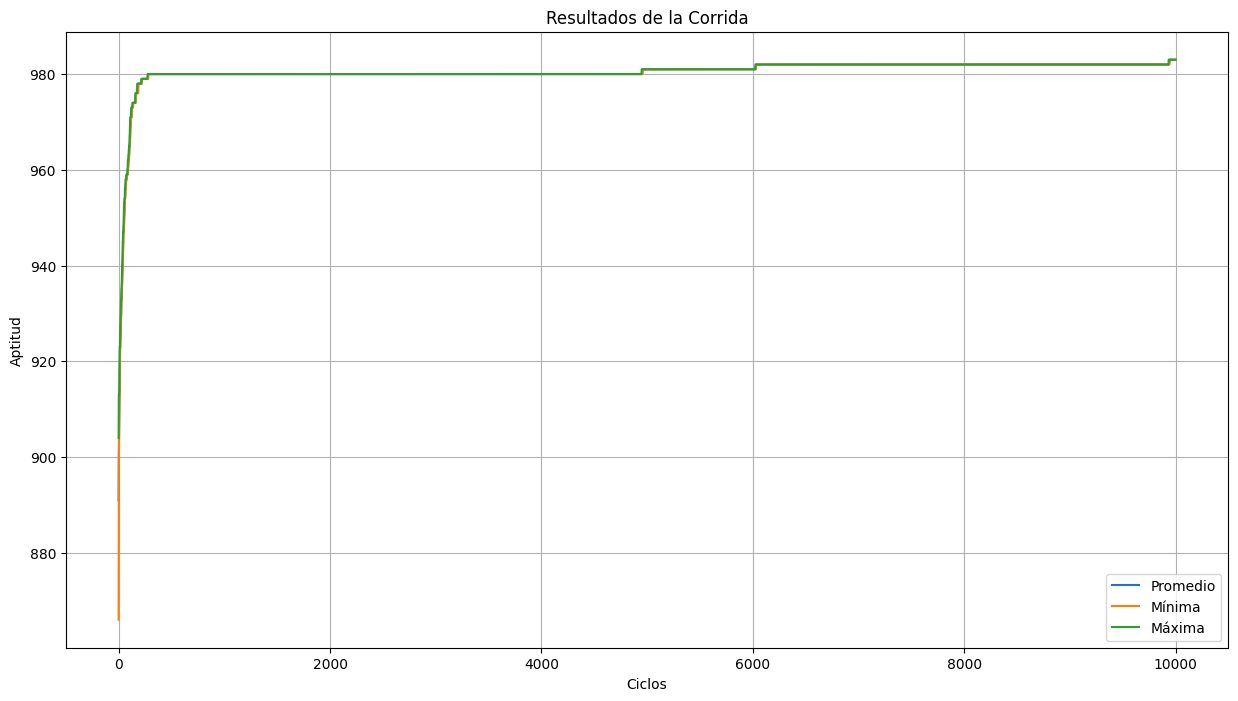

In [12]:
#@title MOSTRAR GRAFICO DE LA CORRIDA
plt.figure(figsize=(15,8))
plt.plot(ciclosPromAptitud)
plt.plot(ciclosMinAptitud)
plt.plot(ciclosMaxAptitud)
plt.title('Resultados de la Corrida')
plt.xlabel('Ciclos')
plt.ylabel('Aptitud')
plt.legend(['Promedio', 'Mínima', 'Máxima'], loc='lower right')
plt.grid(True)
plt.show()
